In [8]:
import os
from pathlib import Path

# Search for dataset_splits.csv across your project folder
base_dir = Path(r"C:\Users\HP\Desktop\projects\plantdiseaseprediction")

found_files = list(base_dir.rglob("dataset_splits.csv"))

if found_files:
    print("Found the file at:")
    for f in found_files:
        print(f.resolve())
else:
    print("File 'dataset_splits.csv' does not exist anywhere under plantdiseaseprediction.")

Found the file at:
C:\Users\HP\Desktop\projects\plantdiseaseprediction\data\dataset_splits.csv


Loaded records: 54305


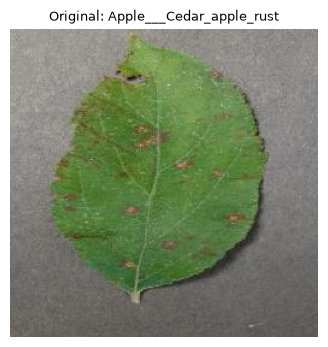

In [9]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load dataset split index from the confirmed path
split_csv_path = Path(r"C:\Users\HP\Desktop\projects\plantdiseaseprediction\data\dataset_splits.csv")
df = pd.read_csv(split_csv_path)

print("Loaded records:", len(df))

# Pick a diseased sample from the training set
sample_record = df[(df["split"] == "train") & (df["class_name"].str.contains("Bacterial_spot|scab|rust"))].iloc[0]
img_path = sample_record["filepath"]
class_name = sample_record["class_name"]

# OpenCV loads in BGR; convert to RGB for proper display
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4, 4))
plt.imshow(img_rgb)
plt.title(f"Original: {class_name}", fontsize=9)
plt.axis("off")
plt.show()

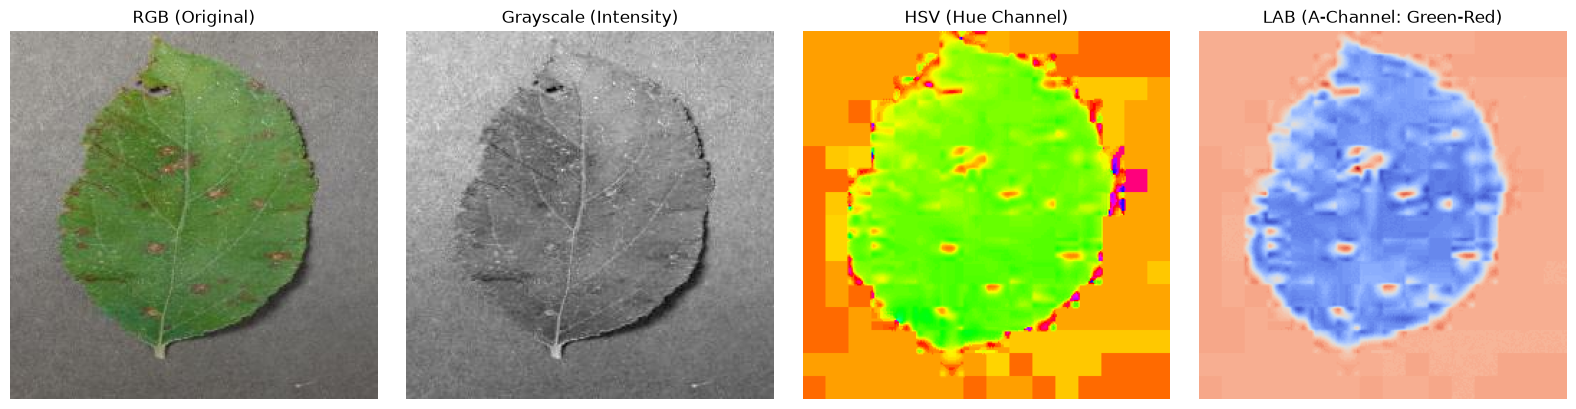

In [10]:
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_rgb)
axes[0].set_title("RGB (Original)")
axes[0].axis("off")

axes[1].imshow(img_gray, cmap="gray")
axes[1].set_title("Grayscale (Intensity)")
axes[1].axis("off")

axes[2].imshow(img_hsv[:, :, 0], cmap="hsv")
axes[2].set_title("HSV (Hue Channel)")
axes[2].axis("off")

axes[3].imshow(img_lab[:, :, 1], cmap="coolwarm")
axes[3].set_title("LAB (A-Channel: Green-Red)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

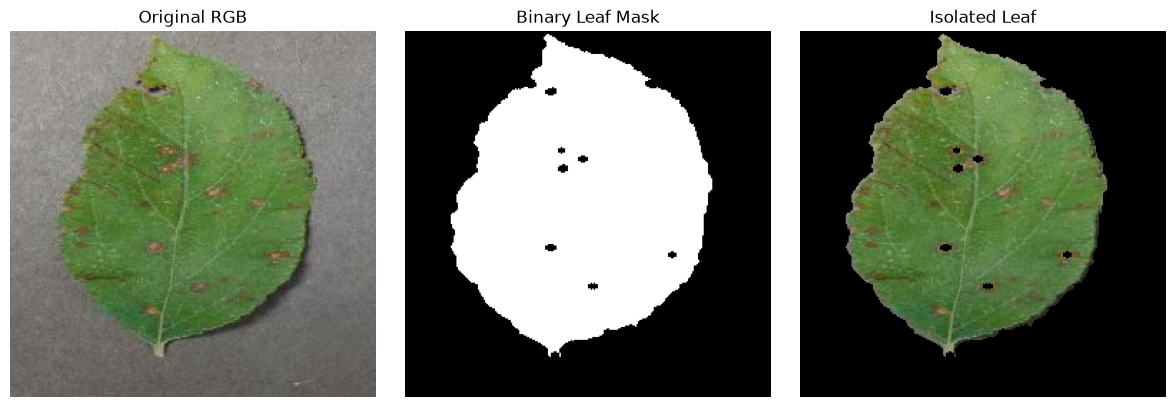

In [11]:
# Range for green/yellow leaf foliage in HSV
lower_green = np.array([25, 40, 40])
upper_green = np.array([90, 255, 255])

# Create binary mask
mask = cv2.inRange(img_hsv, lower_green, upper_green)

# Morphological closing to fill small holes inside the leaf surface
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
mask_cleaned = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# Apply mask onto the RGB image
leaf_segmented = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_cleaned)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_rgb)
axes[0].set_title("Original RGB")
axes[0].axis("off")

axes[1].imshow(mask_cleaned, cmap="gray")
axes[1].set_title("Binary Leaf Mask")
axes[1].axis("off")

axes[2].imshow(leaf_segmented)
axes[2].set_title("Isolated Leaf")
axes[2].axis("off")

plt.tight_layout()
plt.show()

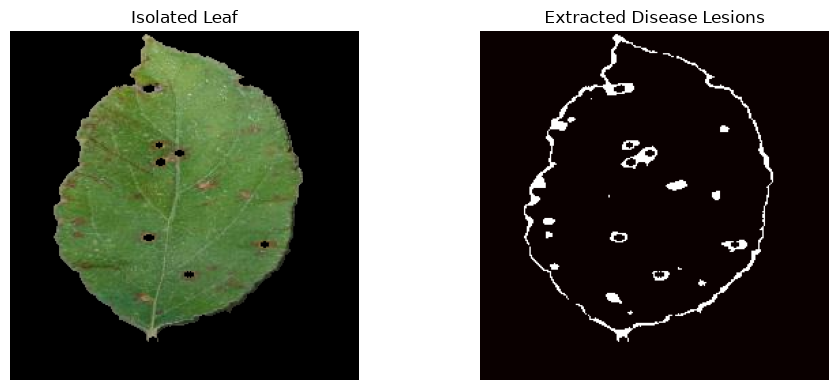

In [12]:
# The 'a' channel in LAB cleanly contrasts green (negative) against red/brown spots (positive)
a_channel = img_lab[:, :, 1]

# Apply Otsu thresholding
_, lesion_mask = cv2.threshold(a_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Constrain lesions strictly within the segmented leaf mask
lesion_mask_bounded = cv2.bitwise_and(lesion_mask, lesion_mask, mask=mask_cleaned)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(leaf_segmented)
axes[0].set_title("Isolated Leaf")
axes[0].axis("off")

axes[1].imshow(lesion_mask_bounded, cmap="hot")
axes[1].set_title("Extracted Disease Lesions")
axes[1].axis("off")

plt.tight_layout()
plt.show()